## **Análisis de comportamiento termodinámico**

In [31]:
import pandas as pd
from funciones import encontrar_equilibrio_hoomd
import os


In [32]:
num_prueba = 14
# Propiedades análisis
polimerizacion = [8]
temperaturas = [0.60]
epsion = [0.25, 2.0]

archivos = []
for polim in polimerizacion:
    for temp in temperaturas:
        for e in epsion:
            estructura_arch = f'log_Poly-Solv_T{temp:.2f}_epsSP{e:.2f}_monom_{polim}.csv'
            archivos.append(estructura_arch)

print(archivos)
print(len(archivos))

# Busqueda de archivos
ruta_memoria = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P14_Polimero_Solvente'
ruta_codigo = '/home/fabio-noriega/Coding/CIATEC/Molecular-Dinamics'


# Filtrado de archivos encontrados
archivos_encontrados = []
for archivo in archivos:
    os.chdir(os.path.join(ruta_memoria))
    if not os.path.exists(archivo):
        print(f'No se encontró el archivo: {archivo}')
    else:
        archivos_encontrados.append(archivo)

os.chdir(ruta_codigo)
print(os.getcwd()) 


['log_Poly-Solv_T0.60_epsSP0.25_monom_8.csv', 'log_Poly-Solv_T0.60_epsSP2.00_monom_8.csv']
2
/home/fabio-noriega/Coding/CIATEC/Molecular-Dinamics


In [33]:
for archivo in archivos:
    df = pd.read_csv(os.path.join(ruta_memoria, archivo))
    num_filas = df.shape[0]
    if num_filas <= 300:
        print(f"🚨 El archivo: {archivo} tiene {num_filas} filas ({num_filas*10_000} pasos). \n Requiere {int((300 - num_filas)*10000)} pasos de integración extras!\n")
    else:
        # print(f"Total de filas ({archivo}): {num_filas} ✅")
        continue
    
    # Se registró cada 10,000 pasos

🚨 El archivo: log_Poly-Solv_T0.60_epsSP2.00_monom_8.csv tiene 74 filas (740000 pasos). 
 Requiere 2260000 pasos de integración extras!



In [34]:
rutas = []
for archivo in archivos:
    df = pd.read_csv(os.path.join(ruta_memoria, archivo))

    ruta_completa = os.path.join(ruta_memoria, archivo)
    paso_equilibrio = encontrar_equilibrio_hoomd(archivo_csv=ruta_completa,
                                                pasos_totales=int(df.shape[0]))
    # Agregamos las rutas analizadas a una lista
    rutas.append(ruta_completa)

print(f"Se analizaron: {len(rutas)} rutas")

❌ Datos insuficientes para crear bloques de promedio.
❌ Datos insuficientes para crear bloques de promedio.
Se analizaron: 2 rutas


In [35]:
# ruta_grafico = os.path.join(prueba)

import matplotlib.pyplot as plt 

for ruta in rutas:
    nombre_leyenda = os.path.basename(ruta).replace('.csv', '')
    # nombre_leyenda = os.path.base(ruta).replace('log_Poly-Solv_', '')
    # print(nombre_leyenda)

    nombre_corto = nombre_leyenda.replace('log_Poly-Solv_', '')
    # print(nombre_corto)
    
    etiqueta_final = nombre_corto.replace('_', ' ')
    print(etiqueta_final)

T0.60 epsSP0.25 monom 8
T0.60 epsSP2.00 monom 8


In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def procesar_datos_termo(archivo_csv):
    """
    Procesa logs de HOOMD de forma adaptativa fila por fila.
    Detecta si el timestep desapareció basándose en el signo de los datos
    y reconstruye el tiempo real de la simulación de forma exacta.
    """
    try:
        steps = []
        pes = []
        current_step = 0
        
        with open(archivo_csv, 'r') as f:
            for linea in f:
                partes = linea.split()
                
                # Intentar convertir los elementos de la línea a números
                try:
                    numeros = [float(p) for p in partes]
                except ValueError:
                    # Si contiene texto (encabezados corruptos), saltamos la línea
                    continue
                
                # Si la línea está vacía o no tiene suficientes datos, saltar
                if len(numeros) < 2:
                    continue
                
                # CRITERIO FÍSICO:
                # Si el primer número es negativo grande (< 0), HOOMD se comió el timestep.
                # Por lo tanto, el primer número es la Energía Potencial.
                if numeros[0] < 0:
                    pe_val = numeros[0]
                    current_step += 10000  # Reconstruimos el paso sumando el intervalo típico
                    step_val = current_step
                else:
                    # El primer número es el Timestep real y el segundo es la Energía Potencial
                    step_val = int(numeros[0])
                    pe_val = numeros[1]
                    current_step = step_val  # Actualizamos el paso actual de control
                
                steps.append(step_val)
                pes.append(pe_val)
                
        if not steps:
            raise ValueError("No se encontraron datos numéricos válidos en el archivo.")
            
        nombre_corto = os.path.basename(archivo_csv).replace('.csv', '')
        
        return {
            'nombre': nombre_corto,
            'step': np.array(steps),
            'pe': np.array(pes)
        }
        
    except Exception as e:
        print(f"❌ Error al procesar {os.path.basename(archivo_csv)}: {e}")
        return None


def graficar_multiples_energias_potenciales(lista_datos, paso_equilibrio=None, ruta_graficos=None, nombre_salida="solapamiento_potencial.png"):
    """
    Toma una lista de diccionarios generados por 'procesar_datos_termo' 
    y solapa todas las curvas de energía potencial en un solo gráfico interactivo.
    """
    fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
    
    # Usamos un mapa de colores que se adapte al número de archivos
    colormap = plt.get_cmap('tab10', max(len(lista_datos), 2))
    
    for idx, datos in enumerate(lista_datos):
        if datos is None:
            continue
            
        step = datos['step']
        pe = datos['pe']
        nombre = datos['nombre']
        color = colormap(idx)
        
        # Si no hay paso de equilibrio, graficar línea continua normal
        if not paso_equilibrio:
            ax.plot(step, pe, color=color, alpha=0.8, label=nombre)
        else:
            # Si hay paso de equilibrio, la etapa previa se atenúa (alpha=0.25)
            mask_pre = step < paso_equilibrio
            mask_post = step >= paso_equilibrio
            
            # Graficar tramo de equilibración (opcional, en tenue para no saturar)
            if any(mask_pre):
                ax.plot(step[mask_pre], pe[mask_pre], color=color, alpha=0.2, linestyle=':')
            
            # Graficar tramo estable (Producción)
            ax.plot(step[mask_post], pe[mask_post], color=color, alpha=0.9, linewidth=1.8, label=nombre)

    # Añadir la línea vertical del punto de equilibrio (una sola vez si existe)
    if paso_equilibrio:
        ax.axvline(x=paso_equilibrio, color='black', linestyle='--', alpha=0.7, label=f'Punto Eq. ({paso_equilibrio})')

    # Estética del gráfico
    ax.set_title("Comparativa de Energías Potenciales", fontsize=14, fontweight='bold')
    ax.set_xlabel("Timestep", fontsize=12)
    ax.set_ylabel("Energía Potencial", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Ajustar leyenda fuera del gráfico por si tienes muchos archivos
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize='small')
    
    # Guardar si se especificó una ruta de carpeta válida
    if ruta_graficos and os.path.isdir(ruta_graficos):
        ruta_completa_salida = os.path.join(ruta_graficos, nombre_salida)
        plt.savefig(ruta_completa_salida, dpi=300, bbox_inches='tight')
        print(f"💾 Gráfico guardado exitosamente en: {ruta_completa_salida}")
    
    # ax.set(xlim=(-1, 3e6))
        
    plt.show()

In [40]:
# Lista para acumular la información de todas tus simulaciones
datos_acumulados = []

for ruta in rutas:
    resultado = procesar_datos_termo(archivo_csv=ruta)
    if resultado:
        datos_acumulados.append(resultado)

💾 Gráfico guardado exitosamente en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P14_Polimero_Solvente/comparativa_energias_potenciales.png


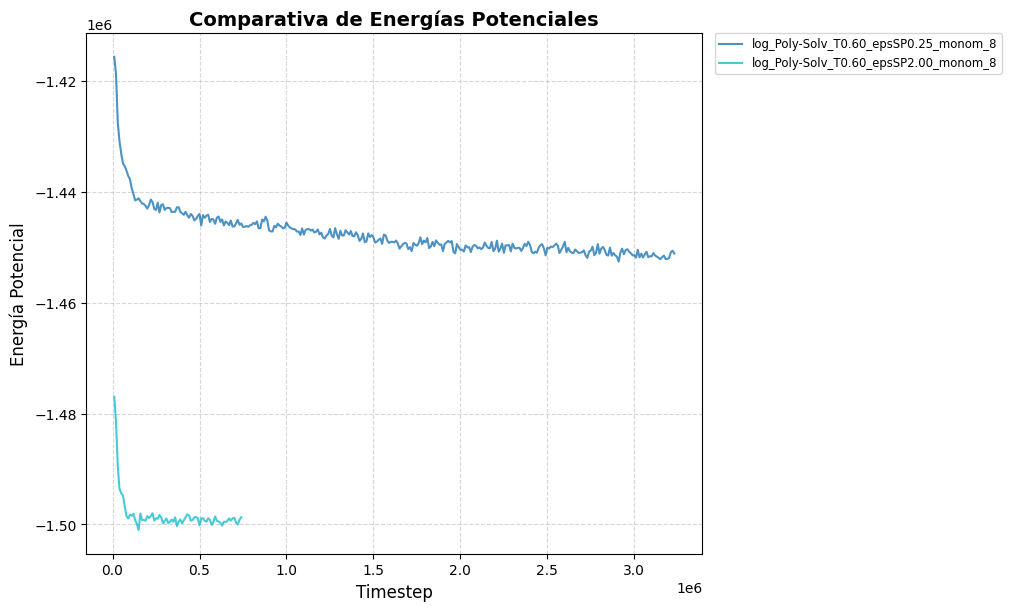

In [41]:
# Aquí pasamos todos los resultados guardados a la vez
graficar_multiples_energias_potenciales(
    lista_datos=datos_acumulados,
    # paso_equilibrio=2.5e6,  # Define tu paso de equilibrio aquí (ej. 150000)
    ruta_graficos=ruta_memoria,       # Tu carpeta de destino
    nombre_salida="comparativa_energias_potenciales.png"
)
